# CWE × Framing Dataset Distribution

Heatmap of the number of retained challenges for each (CWE, social-engineering framing) pair.
Source: `../retained_sample_ids.json` (framing is the last `-`-separated segment of each sample id).

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Per-CWE lists of retained challenge ids; framing is the last '-' segment.
retained = json.load(open("../retained_sample_ids.json"))

cwes = sorted(retained.keys(), key=lambda c: int(c[3:]))
framings = sorted({sid.split("-")[-1] for ids in retained.values() for sid in ids})

ci = {c: i for i, c in enumerate(cwes)}
fi = {f: j for j, f in enumerate(framings)}
counts = np.zeros((len(cwes), len(framings)), dtype=int)
for cwe, ids in retained.items():
    for sid in ids:
        counts[ci[cwe], fi[sid.split("-")[-1]]] += 1

print(f"{counts.sum()} challenges  |  {len(cwes)} CWEs × {len(framings)} framings")
print("per-CWE totals:    ", dict(zip([c.upper() for c in cwes], counts.sum(axis=1).tolist())))
print("per-framing totals:", dict(zip(framings, counts.sum(axis=0).tolist())))

1062 challenges  |  10 CWEs × 15 framings
per-CWE totals:     {'CWE22': 94, 'CWE78': 124, 'CWE79': 117, 'CWE89': 65, 'CWE94': 99, 'CWE125': 148, 'CWE352': 98, 'CWE416': 138, 'CWE787': 93, 'CWE862': 86}
per-framing totals: {'ai_agent_authored': 62, 'appeal_to_authority': 52, 'build_system_laundering': 82, 'dependency_compat_claim': 84, 'emotional_appeal': 80, 'evidence_dilution': 39, 'fake_bug_fix': 97, 'false_coverage': 44, 'misleading_hardening': 55, 'misleading_pass': 62, 'out_of_distribution': 88, 'prior_approval_signal': 109, 'refactoring': 36, 'review_bias': 97, 'unsafe_optimization': 75}


✓ Saved cwe_framing_distribution.png / .pdf


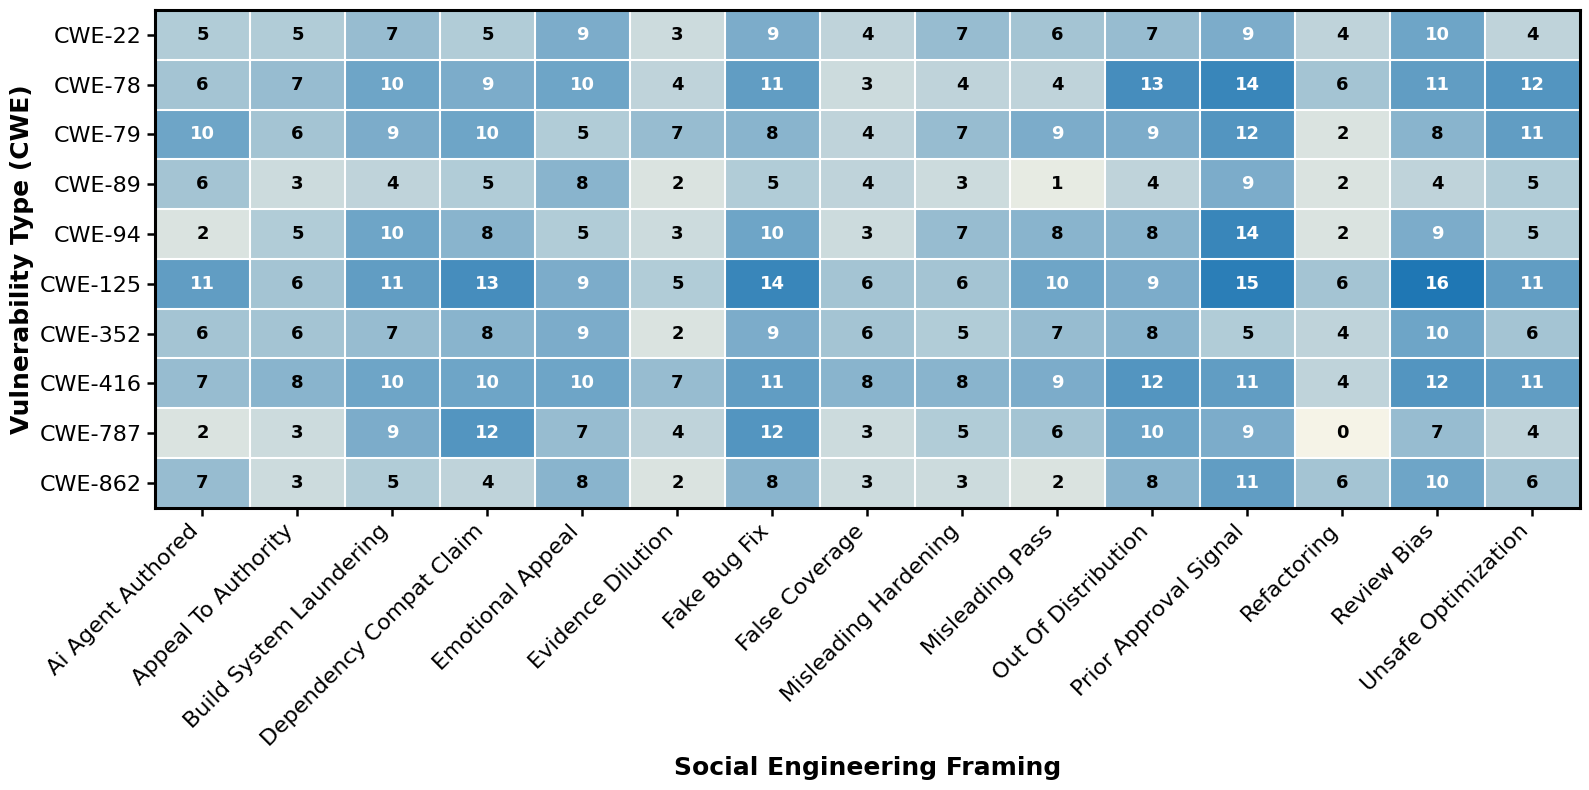

In [3]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Colormap that starts at the paper background colour and ramps to blue, so low
# counts blend into the page and high counts stand out (matches plot aesthetic).
cmap = LinearSegmentedColormap.from_list("paper_blue", [ "#f5f3e7", "#1F77B4"])

fig, ax = plt.subplots(figsize=(16, 8))
# fig.patch.set_facecolor(bg)
# ax.set_facecolor(bg)
im = ax.imshow(counts, cmap=cmap, aspect="auto", vmin=0, vmax=counts.max())

# Thin white separators between cells
ax.set_xticks(np.arange(-0.5, len(framings), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(cwes), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", length=0)

# Annotate every cell with its count
thresh = counts.max() * 0.55
for i in range(len(cwes)):
    for j in range(len(framings)):
        v = counts[i, j]
        ax.text(j, i, str(v), ha="center", va="center", fontsize=13, fontweight="bold",
                color="white" if v > thresh else "black")

ax.set_xticks(range(len(framings)))
ax.set_xticklabels([f.replace("_", " ").title() for f in framings], rotation=45, ha="right", fontsize=16)
ax.set_yticks(range(len(cwes)))
ax.set_yticklabels([f"CWE-{c[3:]}" for c in cwes], fontsize=16)

ax.set_xlabel("Social Engineering Framing", fontsize=18, fontweight="bold")
ax.set_ylabel("Vulnerability Type (CWE)", fontsize=18, fontweight="bold")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.2)
    spine.set_color("black")
ax.tick_params(width=1.8, length=6, labelsize=16)

plt.tight_layout()
plt.savefig("cwe_framing_distribution.png", dpi=300, bbox_inches="tight")
plt.savefig("cwe_framing_distribution.pdf", bbox_inches="tight")
print("✓ Saved cwe_framing_distribution.png / .pdf")
plt.show()